# **Машинное обучение 1, ПМИ ФКН ВШЭ. Бонусное домашнее задание**
##  **Основные методы оценки важности признаков для ML моделей**

В этом домашнем задании вы будете работать с данными о Всемирном отчёте о счастье (World Happiness Report). В качестве теории используйте следующие семинарские материалы: 
- [Основные методы оценки важности признаков для ML моделей](https://github.com/esokolov/ml-course-hse/blob/master/2025-fall/seminars/sem11-xai.ipynb);
- [Интерпретация по определению](https://github.com/esokolov/ml-course-hse/blob/master/2025-fall/seminars/sem11-xai.pdf).

**Общая информация**

**Дата выдачи:** 04.05.2026

**Дедлайн:** 18.05.2026 23:59MSK

**Оценивание и штрафы**

Каждая из задач имеет определенную «стоимость» (указана в скобках около задачи). Максимальная оценка за работу - 5 баллов.

Как всегда, сдача после жёсткого дедлайна невозможна. При выставлении неполного балла за задание в связи с наличием ошибок на усмотрение проверяющего предусмотрена возможность исправить работу на указанных в ответном письме условиях.

Задание выполняется самостоятельно. «Похожие» решения считаются плагиатом и все задействованные студенты (в том числе те, у кого списали) не могут получить за него больше 0 баллов (подробнее о плагиате см. на странице курса). Если вы нашли решение какого-то из заданий (или его часть) в открытом источнике, необходимо указать ссылку на этот источник в отдельном блоке в конце вашей работы (скорее всего вы будете не единственным, кто это нашел, поэтому чтобы исключить подозрение в плагиате, необходима ссылка на источник).


**NB** В этом задании много работ, требующих вывода и размышлений. Куцые выводы, как и неэффективная реализация кода, могут негативно отразиться на оценке.



**Задания сдаются через систему anytask.** Посылка должна содержать:

Ноутбук homework-practice-xai-Username.ipynb
Username - ваша фамилия и имя на латинице именно в таком порядке.


## **Подготовительная часть**

In [16]:
!pip3 install shap -qU


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [17]:
!pip3 install -qU pyALE


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [18]:
!pip3 install -qU lime fat-forensics[all]

zsh:1: no matches found: fat-forensics[all]


### **Подготовка данных**

Загрузите датасет по ссылке.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.svm import SVR

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.inspection import partial_dependence, PartialDependenceDisplay
from sklearn.metrics import mean_squared_error

In [2]:
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)

In [3]:
!wget  -O 'world-happiness-report-2021-prep.csv' -q 'https://www.dropbox.com/scl/fi/vn5d4awcg7n307bnewr2x/world-happiness-report-2021-prep-1.csv?rlkey=yk8sn3fblpvtu8iyc02vpryhp&st=cvysdgto&dl=0'

In [3]:
data_to_work = pd.read_csv('./world-happiness-report-2021-prep.csv')

data_to_work.head(5)

,Ladder score,Logged GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,Dystopia + residual
0,7.842,10.775,0.954,72.0,0.949,-0.098,0.186,3.253
1,7.620,10.933,0.954,72.7,0.946,0.030,0.179,2.868
2,7.571,11.117,0.942,74.4,0.919,0.025,0.292,2.839
3,7.554,10.878,0.983,73.0,0.955,0.160,0.673,2.967
4,7.464,10.932,0.942,72.4,0.913,0.175,0.338,2.798


### Примечание про столбец Dystopia + residual.


В World Happiness Report Dystopia - это не реальная страна, а техническая точка отсчёта: гипотетическая страна с минимальными значениями по ключевым факторам (GDP, social support, life expectancy, freedom, generosity, corruption). Её вводят как бенчмарк, чтобы вклады факторов в разложении были неотрицательными.

Столбец `Dystopia + residual` - это  разложения: базовый уровень (оценка жизни в Dystopia) плюс остаточная часть, которую шесть факторов не объясняют для конкретной страны (ошибка/невязка модели). Это не социальный индекс, а слагаемое, которое вместе с вкладами 6 факторов даёт итоговый score.

Иначе говоря, в таблицах WHR:
Score ~ (вклады 6 факторов) + (Dystopia + residual).

### Поехали дальше

In [4]:
X = data_to_work.drop('Ladder score', axis=1)
y = data_to_work['Ladder score']

Для обучения будем использовать два способа масштабирования - `MinMaxScaler` и `StandardScaler`.

In [5]:
feature_names = list(X.columns)

# Выберем признак для анализа
feature_idx = 1
feature_name = X.columns[feature_idx]

print(f'FEATURE TO ANALYZE: {feature_name}')

FEATURE TO ANALYZE: Social support


In [6]:
# Разделение на тренировочную и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# 1
sc_minmax = MinMaxScaler()
X_train_sc_minmax = sc_minmax.fit_transform(X_train)
X_test_sc_minmax = sc_minmax.transform(X_test)

# 2
sc_standard = StandardScaler()
X_train_sc_standard = sc_standard.fit_transform(X_train)
X_test_sc_standard = sc_standard.transform(X_test)

### **Задание 1. (0.5 балла)**
- Обучите 6 моделей:
  -  линейную регрессию (`LinearRegression`) на двух вариантах данных;
  - Lasso регрессию (`Lasso`) на двух вариантах данных;
  - градиентный бустинг (`GradientBoostingRegressor`) на двух вариантах данных;
- Выведите MSE и RMSE моделей.
- Зафиксируйте выводы.

> Цель задания - увидеть, какие модели чувствительны к масштабу признаков (Lasso), а какие почти инвариантны (LR/деревья), и почему это важно для интерпретации.


**NB:** Для бустингов ограничьте глубину до 5.

In [7]:
print('Linear Regression')

print('MinMax:')

lr_minmax_model = LinearRegression()
lr_minmax_model.fit(X_train_sc_minmax, y_train)
MSE = mean_squared_error(lr_minmax_model.predict(X_test_sc_minmax), y_test)
print(f'Test: MSE={MSE:0.9f}; RMSE={MSE**0.5:0.9f}')

print('Standard:')

lr_standard_model = LinearRegression()
lr_standard_model.fit(X_train_sc_standard, y_train)
MSE = mean_squared_error(lr_standard_model.predict(X_test_sc_standard), y_test)
print(f'Test: MSE={MSE:0.9f}; RMSE={MSE**0.5:0.9f}')



print('\nLasso')

print('MinMax:')

lasso_minmax_model = Lasso(alpha=0.05)
lasso_minmax_model.fit(X_train_sc_minmax, y_train)
MSE = mean_squared_error(lasso_minmax_model.predict(X_test_sc_minmax), y_test)
print(f'Test: MSE={MSE:0.9f}; RMSE={MSE**0.5:0.9f}')

print('Standard:')

lasso_standard_model = Lasso(alpha=0.05)
lasso_standard_model.fit(X_train_sc_standard, y_train)
MSE = mean_squared_error(lasso_standard_model.predict(X_test_sc_standard), y_test)
print(f'Test: MSE={MSE:0.9f}; RMSE={MSE**0.5:0.9f}')


print('\nGradient Boosting')

print('MinMax:')

gb_minmax_model = GradientBoostingRegressor(max_depth=5)
gb_minmax_model.fit(X_train_sc_minmax, y_train)
MSE = mean_squared_error(gb_minmax_model.predict(X_test_sc_minmax), y_test)
print(f'Test: MSE={MSE:0.9f}; RMSE={MSE**0.5:0.9f}')

print('Standard:')

gb_standard_model = GradientBoostingRegressor(max_depth=5)
gb_standard_model.fit(X_train_sc_standard, y_train)
MSE = mean_squared_error(gb_standard_model.predict(X_test_sc_standard), y_test)
print(f'Test: MSE={MSE:0.9f}; RMSE={MSE**0.5:0.9f}')

Linear Regression
MinMax:
Test: MSE=0.000000984; RMSE=0.000992064
Standard:
Test: MSE=0.000000984; RMSE=0.000992064

Lasso
MinMax:
Test: MSE=0.136233715; RMSE=0.369098517
Standard:
Test: MSE=0.008343605; RMSE=0.091343338

Gradient Boosting
MinMax:
Test: MSE=0.157565192; RMSE=0.396944823
Standard:
Test: MSE=0.152757500; RMSE=0.390842040


Вывод:
- У обычной регрессии ошибка не меняется совсем, так как оба варианта масштабирования - линейные преобразования и не влияют на процесс обучения (кроме потери точности при операциях с float)
- У Lasso ошибка меньше у Standard, так как там:
  1. Больше размах => следовательно нужны коэффициенты меньше => меньше штрафуются и больше сохраняется информации о данных
  2. Одинаковые дисперсии у признаков, в отличии от MinMax, что не дает преимущества одним признакам перед другими
- При масштабировании сохраняется отсортированность признаков => следовательно для деревьев с условиями feauture <= t в узлах разницы между данными нет

## **1. Интерпретация по определению**

Воспользуемся встроенными важностями в моделях. Для бустинга — усредненная важность по деревьям, для регрессий — коэффициенты.

### **Задание 2. (0.25 балла)**
- Постройте график (любой, на ваш выбор), позволяющий визуально оценить и сравнить коэффициенты по парам моделей:
  - Модель и `StandardScaler` vs Модель и `MinMaxScaler`
- Зафиксируйте выводы по каждой из пар графиков.

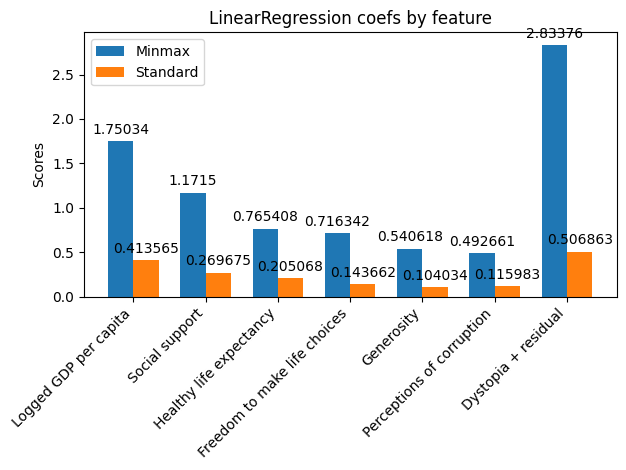

In [8]:
minmax_coef = np.abs(lr_minmax_model.coef_)
standard_coef = np.abs(lr_standard_model.coef_)
labels = X_train.columns

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots()
rects1 = ax.bar(x - width/2, minmax_coef, width, label='Minmax')
rects2 = ax.bar(x + width/2, standard_coef, width, label='Standard')

ax.set_ylabel('Scores')
ax.set_title('LinearRegression coefs by feature')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

ax.bar_label(rects1, padding=3)
ax.bar_label(rects2, padding=3)

plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

fig.tight_layout()
plt.show()

**Ваш вывод здесь:** векторы коэффициентов пропорциональны - важность не зависит от способа масштабирования

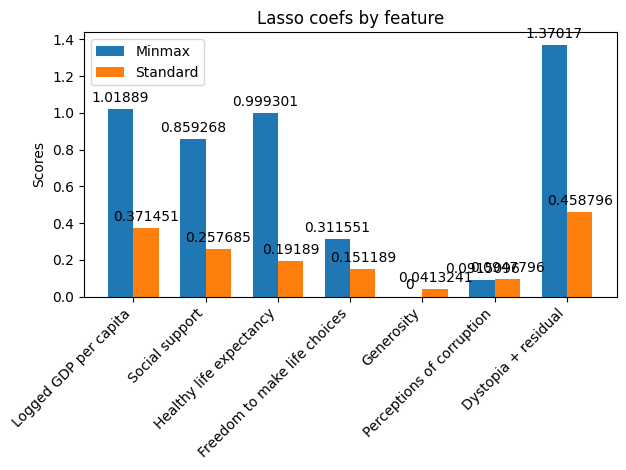

In [9]:
minmax_coef = np.abs(lasso_minmax_model.coef_)
standard_coef = np.abs(lasso_standard_model.coef_)
labels = X_train.columns

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots()
rects1 = ax.bar(x - width/2, minmax_coef, width, label='Minmax')
rects2 = ax.bar(x + width/2, standard_coef, width, label='Standard')

ax.set_ylabel('Scores')
ax.set_title('Lasso coefs by feature')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

ax.bar_label(rects1, padding=3)
ax.bar_label(rects2, padding=3)

plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

fig.tight_layout()
plt.show()

**Ваш вывод здесь:** видим, что для MinMax масштабирования Lasso занулила коэффициент - из-за меньшего масштаба коэффициента в сравнении с Standard и из-за того, что у Generosity дисперсия меньше, чем у остальных признаков, что сглаживается Standard-ом, но не MinMax-ом. Так же видим, что в MinMax-е менее равномерно распределены важности признаков по тем же причинам

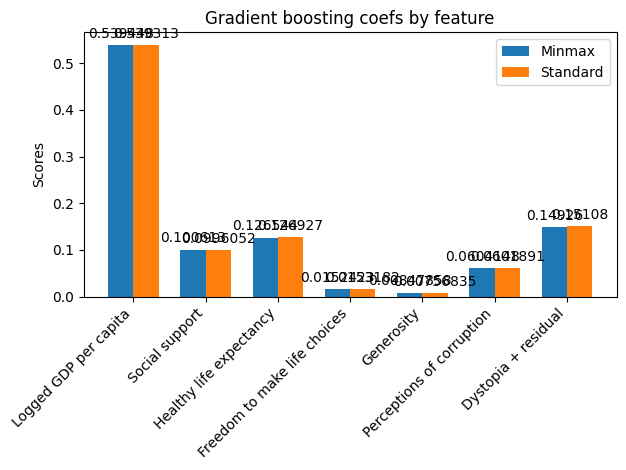

In [10]:
minmax_coef = np.abs(gb_minmax_model.feature_importances_)
standard_coef = np.abs(gb_standard_model.feature_importances_)
labels = X_train.columns

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots()
rects1 = ax.bar(x - width/2, minmax_coef, width, label='Minmax')
rects2 = ax.bar(x + width/2, standard_coef, width, label='Standard')

ax.set_ylabel('Scores')
ax.set_title('Gradient boosting coefs by feature')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

ax.bar_label(rects1, padding=3)
ax.bar_label(rects2, padding=3)

plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

fig.tight_layout()
plt.show()

**Ваш вывод здесь:** важность не поменялась даже пропорционально, так как дереву важен порядок элементов относительно друг друга, а не масштаб

### **Задание 3. (0.25 балла)**
Вернитесь к графику линейной регрессии. Очевидно, что коэффициенты одной модели связаны с коэффициентами другой. Как перейти от одних к другим? Реализуйте это в коде, как для свободного члена, так и для самих коэффициентов.

> Идея: коэффициенты линейной модели можно сравнивать как важности только при фиксированном масштабе. Вывод формулы перехода - способ строго показать, что коэффициенты меняются предсказуемо и не являются абсолютной важностью.

**Ваши теоретические выкладки здесь:**

Пусть у MinMax-модели коэффициенты $\omega_0, \dots, \omega_k$, то есть:
$$
a(x) = \omega_0 + \sum_{i=1}^k{\omega_k\frac{x_k - k_{min}}{k_{max} - k_{min}}} = \omega_0 - \sum_{i=1}^k{\omega_k\frac{k_{min}}{k_{max} - k_{min}}} + \sum_{i=1}^k{(\frac{\omega_k}{k_{max} - k_{min}})x_k}
$$

Пусть $a(x) = \omega_0 + \omega_1x_1 + \dots + \omega_kx_k$ - обычная регрессия, тогда:

$$
a(x) = \omega_0 + \sum_{i=1}^k{w_ix_i} = \omega_0 + \sum_{i=1}^n{\mu_iw_i} + \sum_{i=1}^n{(\omega_i\sigma_i)\frac{(x_i-\mu_i)}{\sigma_i}}
$$

нетрудно заметить, что для перехода между весами достаточно поделить на стандартное отклонение MinMax-масштабированных данных, так как здесь умножение пропорционально изменяет вектор стандартных отклонений по признакам

In [11]:
# ваш код здесь

results = dict()
results['lr_standard'] = [lr_standard_model]

mx = X_train.max(axis=0)
mn = X_train.min(axis=0)

base_model_coef = lr_minmax_model.coef_ / (mx - mn)
base_model_intercept = lr_minmax_model.intercept_ - (lr_minmax_model.coef_ * mn / (mx - mn)).sum()

coef_std = lr_minmax_model.coef_ * X_train_sc_minmax.std(axis=0)
intercept_std = base_model_intercept + (base_model_coef * X_train.mean(axis=0)).sum()


assert round(intercept_std, 4) == round(results['lr_standard'][0].intercept_, 4)
assert all(np.round(coef_std, 4) == np.round(results['lr_standard'][0].coef_, 4))

## **1. Plot-based методы**

Рассмотрев тонкости работы с масштабированием, поработаем с plot-based методами. Оставьте теперь для анализа линейную регрессию и бустинг, обученные на MinMaxScaler.

In [12]:
lr_minmax = lr_minmax_model # модель LinearRegression, обученная на X_train_sc_minmax
gb_minmax = gb_minmax_model # модель GradientBoostingRegressor, обученная на X_train_sc_minmax

### **1. 1. ICE**

**Построение:**

1. Зафиксируем множество $X_{test}$ и некоторый признак $j$. Пусть  $j$ имеет $m$ уникальных значений $[j_1, j_2, ..., j_m]$.

2. Исходный датасет  $X_{test}$ дублируем  $m$ раз: $$X'_1, X'_2, ..., X'_m,$$ так, что для датасета $X'_i$ значение признака $j$ есть $j_i$;

3. На каждом $X'_i$ рассчитываем прогноз модели $f(X'_i)$&

4. На графике строим линии для каждого объекта, показывающие как прогноз (ось $y$) меняется при изменении признака (ось $x$);

### **Задание 4. (0.5 балла)**

Мы знаем, что признаки модели масштабированы определенным образом. Минимум каждого признака равен 0, максимум 1. Что будет с моделями, если признаки выйдут из диапазона?
- Работая с тем же признаком, изучите его **исходные** минимум и максимум. Сделайте искусственный диапазон из 20 точек, равный $[max, 3*max]$.
- На полученном диапазоне постройте ICE для обеих моделей. ICE стройте собственноручно, без использования sklearn.
- Зафиксируйте выводы


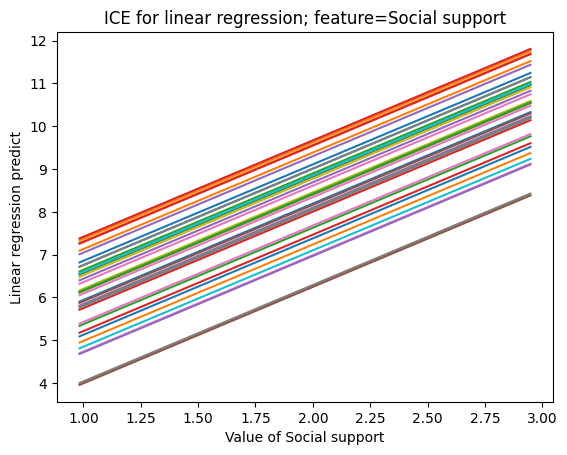

In [13]:
min_value, max_value = X_train[feature_name].min(), X_train[feature_name].max()
vals = np.linspace(start=max_value, stop=max_value * 3, num=20)
vals_scaled = (vals - min_value) / (max_value - min_value)

for ind in range(len(X_test)):
    row_df = np.repeat(X_test_sc_minmax[ind:ind+1, :], 20, axis=0)
    row_df[:, feature_idx] = vals_scaled
    preds = lr_minmax.predict(row_df)
    plt.plot(vals, preds)

plt.title(f'ICE for linear regression; feature={feature_name}')
plt.xlabel('Value of Social support')
plt.ylabel('Linear regression predict')

plt.show()

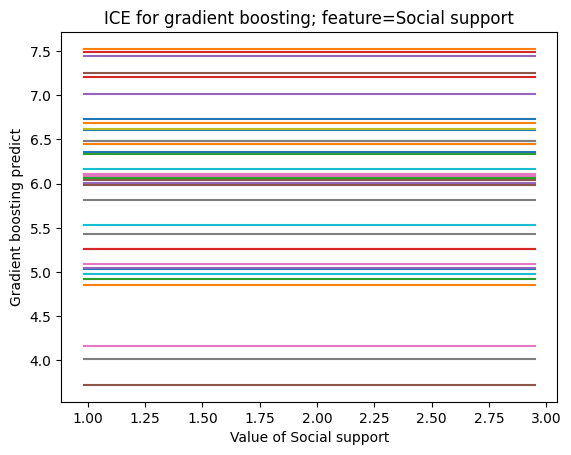

In [14]:
min_value, max_value = X_train[feature_name].min(), X_train[feature_name].max()
vals = np.linspace(start=max_value, stop=max_value * 3, num=20)
vals_scaled = (vals - min_value) / (max_value - min_value)

for ind in range(len(X_test)):
    row_df = np.repeat(X_test_sc_minmax[ind:ind+1, :], 20, axis=0)
    row_df[:, feature_idx] = vals_scaled
    preds = gb_minmax.predict(row_df)
    plt.plot(vals, preds)

plt.title(f'ICE for gradient boosting; feature={feature_name}')
plt.xlabel('Value of Social support')
plt.ylabel('Gradient boosting predict')

plt.show()

**Ваш вывод здесь:**
поскольку у нас линейная регрессия не содержит полиномов степени выше 1, то влияние каждого признака строго линейное на прогресс вне зависимости от других признаков

у бустинга прогнозы постоянные относительно значения признака, так как деревья не продолжают свои решения дальше обучающей выборки ( строят сплит так, чтобы в каждом поддереве было хотя бы по 1 объекту, поэтому при значении >= максимального предсказания будут одинаковыми ) 

### **1. 2. PDP**

Теперь посмотрим на усредненнуе влияние признака.
### **Задание 5. (0.25 балла)**

- Усредните ICE по обеим моделям, используя PDP из sklearn.
- Сделайте выводы.


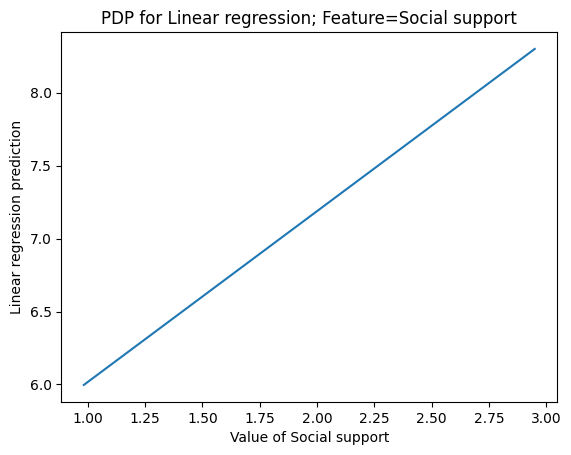

In [15]:
results = partial_dependence(lr_minmax, X_test_sc_minmax, [feature_idx], custom_values={feature_idx: vals}, grid_resolution=20, kind='average')

plt.plot(results['grid_values'][0], results['average'][-1])

plt.title(f'PDP for Linear regression; Feature={feature_name}')
plt.xlabel(f'Value of {feature_name}')
plt.ylabel('Linear regression prediction')

plt.show()

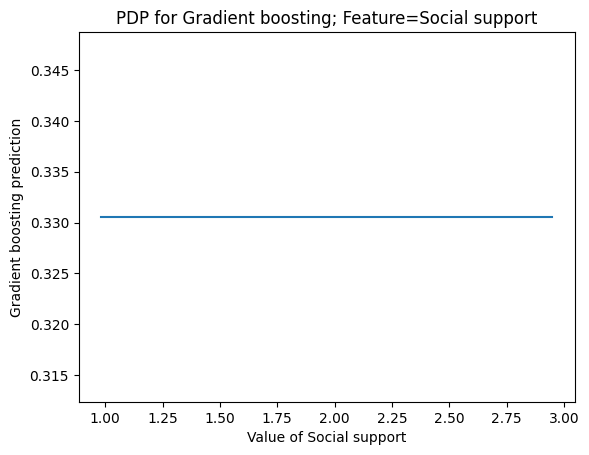

In [16]:
results = partial_dependence(gb_minmax, X_test_sc_minmax, [feature_idx], custom_values={feature_idx: vals}, grid_resolution=20, kind='average')

plt.plot(results['grid_values'][0], results['average'][-1])

plt.title(f'PDP for Gradient boosting; Feature={feature_name}')
plt.xlabel(f'Value of {feature_name}')
plt.ylabel('Gradient boosting prediction')

plt.show()

**Ваш вывод здесь:**

вывод аналогичен предыдущему пункту - для линейной регрессии влияние на каждом объекте линейное ( причем с одинаковым коэффициентом для всех объектов), а значит, и для усредненного значения аналогичный результат

для бустинга все предсказания константы, так как не обучены на значение признака выше максимума, и поэтому в усредненном предсказании видим также константность относительно значения Social support

### **1. 3. Accumulated Local Effects (ALE)**

Заключительный из основных графических методов — ALE. Ради практики построим и его.

### **Задание 6. (0.5 балла)**

- Постройте ALE по обеим моделям, используя pyALE. (0.15)
- Подберите размер сетки так, чтобы получить доверительные интервалы. (0.05)
- Проанализируйте полученный график. Каковы получились ДИ? Почему они различны для моделей? (0.3)

> Важно: сетку значений строим в исходных единицах признака, но перед подачей в модель применяем тот же scaler, на котором обучение.

PyALE._ALE_generic:INFO: Continuous feature detected.


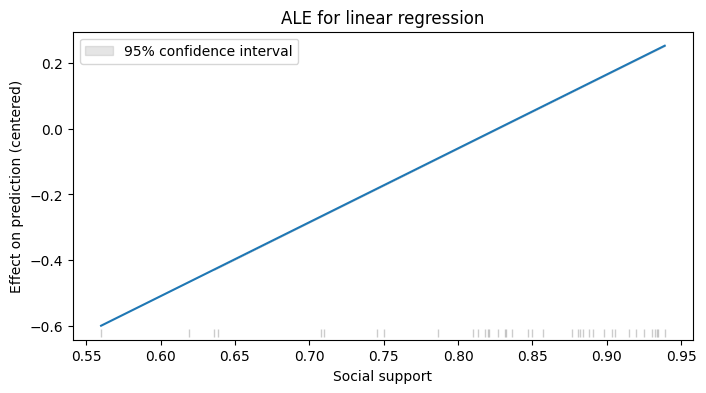

In [17]:
from PyALE import ale
from sklearn.pipeline import Pipeline

model = Pipeline([
    ('minmax', sc_minmax),
    ('regression', lr_minmax),
])

feature_names = list(X.columns)

ale_eff = ale(
    X=pd.DataFrame(X_test, columns=feature_names), model=model, feature=[feature_name], grid_size=15, C=0.95
)

plt.title('ALE for linear regression')

plt.show()

PyALE._ALE_generic:INFO: Continuous feature detected.


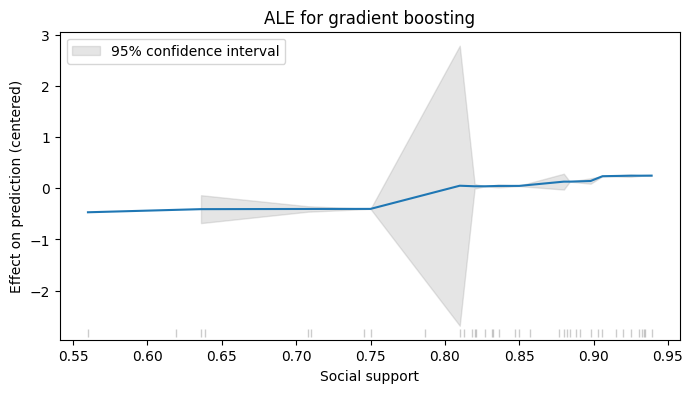

In [18]:
from PyALE import ale

model = Pipeline([
    ('minmax', sc_minmax),
    ('boosting', gb_minmax),
])

feature_names = list(X.columns)

ale_eff = ale(
    X=pd.DataFrame(X_test, columns=feature_names), model=model, feature=[feature_name], grid_size=15, C=0.95
)

plt.title('ALE for gradient boosting')

plt.show()

**Ваши выводы здесь:**

вклад признака в результат линейной регресии постоянен и не зависит от других переменных - поэтому доверительный интервал схлопывается в одну точку ( в частности из-за нулевой дисперсии смещений предсказания от смещения по исследуемому признаку)

бустинг - видим нестабильное значение как важности так и доверительного интервала для важности признака, так как влияние признака на результат сильно зависит от других переменных ( где зависимость сильная - больше доверительный интервал)

## **2. Permutation importances**

Практикуем ещё один метод.
### **Задание 7. (0.25 балла)**

- Постройте Permutation importances по обеим моделям, используя sklearn
- Поэкспериментируйте с числом перестановок. (0.05)
- Проанализируйте полученные коэффициенты. Как они меняются от количества перестановок? Как меняются std коэффициентов? Зафиксируйте выводы. (0.20)

In [19]:
from sklearn.inspection import permutation_importance

perm_results = permutation_importance(lr_minmax,
                                      X_train_sc_minmax,
                                      y_train,
                                      scoring='neg_mean_squared_error',
                                      n_repeats=10,
                                      random_state=17)

permutation_imp_data = pd.DataFrame(perm_results.importances_mean, columns=['importances'], index=X_train.columns)
permutation_imp_data['importances_std'] = perm_results.importances_std

permutation_imp_data

,importances,importances_std
Logged GDP per capita,0.327324,0.023157
Social support,0.142155,0.012432
Healthy life expectancy,0.082744,0.004052
Freedom to make life choices,0.041568,0.003071
Generosity,0.022368,0.002228
Perceptions of corruption,0.027068,0.002583
Dystopia + residual,0.510844,0.050031


In [20]:
from sklearn.inspection import permutation_importance

perm_results = permutation_importance(gb_minmax,
                                      X_train_sc_minmax,
                                      y_train,
                                      scoring='neg_mean_squared_error',
                                      n_repeats=10,
                                      random_state=17)

permutation_imp_data = pd.DataFrame(perm_results.importances_mean, columns=['importances'], index=X_train.columns)
permutation_imp_data['importances_std'] = perm_results.importances_std

permutation_imp_data

,importances,importances_std
Logged GDP per capita,0.553069,0.070099
Social support,0.108594,0.007588
Healthy life expectancy,0.103589,0.013673
Freedom to make life choices,0.016925,0.002269
Generosity,0.005612,0.001406
Perceptions of corruption,0.060744,0.008303
Dystopia + residual,0.335461,0.032509


**Ваши выводы здесь:**

значения важности +- совпадают по моделям ( относительно друг друга ).

самое большое различие - в LR самый важный признак - Dystopia + residual, в GB - Logger GDP per capita. как было сказано в начале, Dystopia + residual - слагаемое невязки, значит оно лучше работает в модели линейной регрессии, где его можно напрямую прибавить к результату.

при изменении числа повторов коэффициенты практически не меняются - ввиду усреднения оценки по всем итерациям перемешивания получаемые коэффициенты по ЗБЧ стремятся по вероятности к истинному значению, причему ввиду достаточно малой дисперсии сходятся они быстро. дисперсия каждой отдельной перестановки - сама по себе несмещенная оценка на дисперсию, поэтому она также не будет меняться

### **Задание 8. (0.5 балла)**

Идея перестановочной важности представляет собой частный случай важности при помощи внесения **возмущений** в признак. Возмущения могут быть разных видов:

- внесение случайного шума;
- зануление признака (удобно для изображений);
- сдвиг признака к его базовому значению и оценка траектории изменения прогнозов или качества модели;

В этом задании попробуем построить оценку на основе сдвига к базовому значению траектории. Примем за базовое значение медиану признака и будем сдвигать исходный признак к медианному с некоторым коэффициентом $\beta$:

$$x_j^{(\beta)}=(1-\beta)x_j+\beta b_j$$

где $b_j$ – медиана признака. Важность будем оценивать как изменение MSE по тест-данным.

1. Реализуйте это возмущение. Как меняются важности при разных $\beta$?
2. Постройте bar-график и сравните ранжирование с **permutation importance**. При сравнении, анализируйте только числовые признаки.


Для регрессии эффект очевиден, поэтому эту окклюзию оценивайте только для бустинга.
**Подсказка:**

1. Выберите базовые значения $x_j$ как **медианы по train** (базовые значения обозначим за $b_j$);
2. На тренировочном наборе данных для каждого признака $j$ замените столбец $x_j$ на $x^{(\beta)}_j=(1-\beta)x_j+\beta b_j$ при разных $\beta$, равных $[0.2, 0.5, 1]$.
3. Посчитайте $\Delta L_j = \text{MSE}(y,\hat y^{(\beta)}_j)-\text{MSE}(y,\hat y)$. Чем больше $\Delta L_j$, тем важнее признак.



In [21]:
def occlusion_importance(X_train, y_train, model, feature, beta=1.0):
    med = X_train[feature].median()
    y_pred = model.predict(X_train)
    X_train[feature] = (1.0 - beta) * X_train[feature] + beta * med
    y_hat_pred = model.predict(X_train)
    return mean_squared_error(y_train, y_hat_pred) - mean_squared_error(y_train, y_pred)

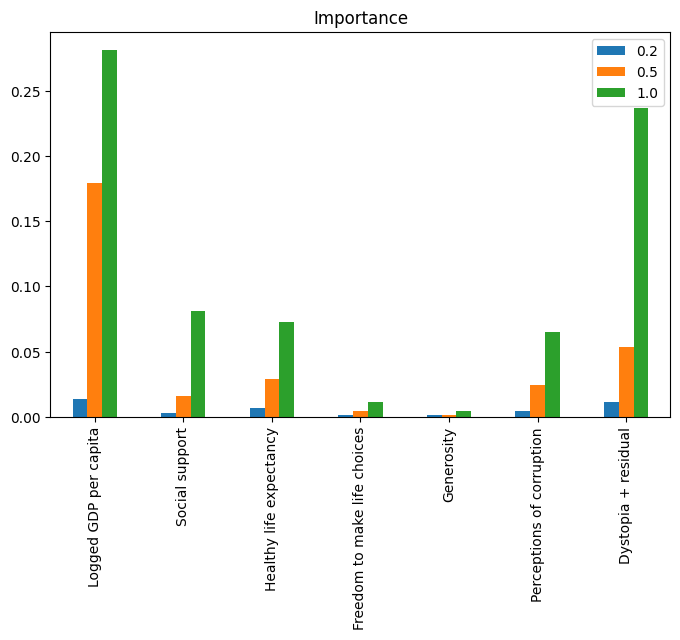

In [42]:
res = {
    0.2: [],
    0.5: [],
    1.0: [],
}
for beta in betas:
    for feature in feature_names:
        res[beta].append(
            occlusion_importance(pd.DataFrame(X_train_sc_minmax, columns=feature_names), y_train, gb_minmax, feature, beta)
        )

df = pd.DataFrame(res, index=feature_names)
df.plot(kind='bar', figsize=(8, 5))

plt.title('Importance')

plt.show()

**Ваши выводы здесь:** совпадает с тем, что мы видели при permutation importances

## **3. SHAP**

Теперь проведем локальный анализ, используя SHAP и LIME. Но для shap также построим глобальные графики.

### **Задание 9. (0.5 баллa)**
- Постройте два глобальных графика, используя SHAP. Как один из них обязательно используйте `force`, как другой — выберите любой из документации. (0.25 балл)
- Проанализируйте важность признаков в обоих алгоритмах.(0.25 балл)

**NB:** Для линейного алгоритма используйте masker=`shap.maskers.Independent(data=X_train_sc)`. Он имитирует отсутствие признака

In [40]:
import shap
# Ваш код здесь

In [41]:
# Ваш код здесь

 **Ваш вывод здесь:**

## **Локальное объяснение.**

### **Задание 10. (0.25 балла)**
- Постройте локальный график с SHAP для объекта с индексом 7 на обеих моделях и сделайте выводы.

In [42]:
# Ваш код здесь

In [43]:
# Ваш код здесь

**Ваш вывод здесь:**

### **Теория: SHAP + categorical**


SHAP разлагает предсказание модели $f(x)$ на базовый уровень $\phi_0=\mathbb E[f(X)]$ и сумму вкладов признаков:

$$
f(x)=\phi_0+\sum_{j=1}^p \phi_j(x).
$$

Значение $\phi_j(x)$ — это «маржинальный вклад» признака $j$ вблизи точки $x$, усреднённый по всем коалициям признаков. Сумма SHAP по признакам всегда совпадает с предсказанием относительно базовой линии — отсюда удобство интерпретации и сравнимость вкладов.

Однако, вопреки этому удобству, SHAP имеет ограничения при работе с категориальными данными в разных кодировках.


1. OneHotEncoding. В этом случае каждому столбцу присвается свое значение Шепли. Общий вклад здесь — всегда **сумма** dummy-столбцов.
2. В CatBoost используется особый способ категориального разбиения, который (при использовании) фактически создаёт новые признаки для разбиения, отсутствующие в исходном наборе входных признаков. Эти признаки позволяют разбивать целые группы категорий тем или иным образом. Поддержка таких типов деревьев пока не реализована в SHAP, но можно использовать в CatBoost — встроенные [ShapValues](https://catboost.ai/docs/en/concepts/shap-values).
3. При других типах кодировок важно проверять отсутствие утечки.



## **4. LIME**

### **Задание 11. (0.25 балла)**
- Постройте локальный график с LIME для объекта с индексом 7 на обеих моделях и сделайте выводы. Сравните графики с SHAP. Ядро используйте как в семинаре — `kernel_width=np.sqrt(len(feature_names)) * 0.75`

In [44]:
from lime.lime_tabular import LimeTabularExplainer

# Ваш код здесь

ModuleNotFoundError: No module named 'lime'

In [ ]:
# Ваш код здесь

### **Задание 12. (1 балл)**

Теперь сделаем LIME собственноручно. Ваша реализация должна:

- Принимать на вход точку `x0`
- Вокруг этой точки данных сэмплировать окрестность заданного размера `n`
- На данных из этой окрестности получать прогнозы объясняемой модели (учитывать веса объектов, используя ядро)
- Обучать LIME модель в виде стандартной линейной регрессии
- Возвращать коэффициенты локальной модели


Для своей реализации оцените устойчивость. Как влияет на коэффициенты количество сгенерированных точек? А выбор ядра?

**В реализации вам может помочь библиотека `fatf`**
**Свой LIME тестируйте только для бустинга.**

In [ ]:
# Ваш код здесь — функция

In [ ]:
# Ваш код здесь применение на бустинге

 **Ваш вывод здесь:**

## **Вы проделали огромную работу! Ура!**